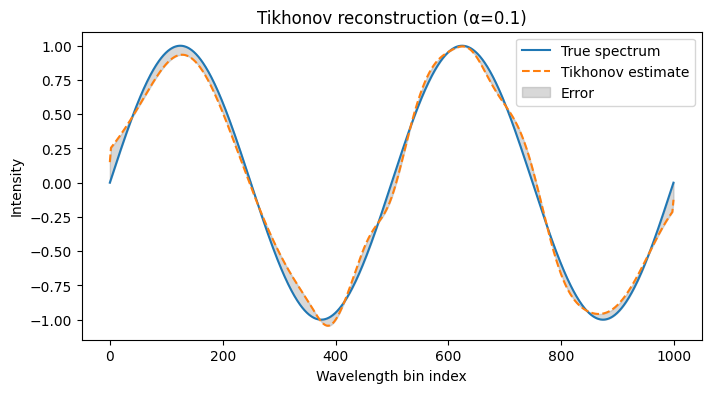

In [1]:
#TIKHONOV TEST

import os, sys
import numpy as np
import matplotlib.pyplot as plt

parent_dir = os.path.abspath('..')
sys.path.insert(0, parent_dir)
from src.models.tikhonov import TikhonovInverter

# load and prepare
R      = np.load("../data/responsivity_data/processed/responsivity.npy")  # (1000,41)
A      = R.T                                        # (41,1000)
alpha  = 0.1
solver = TikhonovInverter(alpha=alpha)
solver.set_matrix(A)

# create a smooth test spectrum and noisy measurement
n = A.shape[1]
x_true = np.sin(np.linspace(0, 4*np.pi, n))
b      = A @ x_true + 0.01 * np.random.randn(A.shape[0])

# solve
x_est = solver.solve(b)

# plot
plt.figure(figsize=(8,4))
plt.plot(x_true, label="True spectrum")
plt.plot(x_est, "--", label="Tikhonov estimate")
plt.fill_between(np.arange(n),
                 x_true, x_est,
                 color="gray", alpha=0.3,
                 label="Error")
plt.legend()
plt.title(f"Tikhonov reconstruction (α={alpha})")
plt.xlabel("Wavelength bin index")
plt.ylabel("Intensity")
plt.show()